In [1]:
from google.colab import drive
drive.mount('/content/drive')

project_root = "/content/drive/MyDrive/pdm_project"
print("Drive mounted ✅")



Mounted at /content/drive
Drive mounted ✅


In [2]:
import os

folders = [f"{project_root}/data/CWRU_raw", f"{project_root}/data/ESPset_raw"]
for f in folders:
    os.makedirs(f, exist_ok=True)
print("Folders ready ")


Folders ready 


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# define the base folder for your project
project_root = "/content/drive/MyDrive/pdm_project"
print("Drive mounted and project_root defined ✅")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and project_root defined ✅


In [4]:
!pip install kaggle


In [5]:
import zipfile, os

zip_path = f"{project_root}/data/CWRU_raw/CWRU_Bearing_NumPy-main.zip"
extract_to = f"{project_root}/data/CWRU_raw"

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("✅ Unzipped successfully to:", extract_to)


✅ Unzipped successfully to: /content/drive/MyDrive/pdm_project/data/CWRU_raw


In [6]:
import os

data_path = f"{project_root}/data/CWRU_raw/CWRU_Bearing_NumPy-main/Data"
files = os.listdir(data_path)
print("📦 Files found:", len(files))
print("First 10 files:", files[:10])


📦 Files found: 4
First 10 files: ['1730 RPM', '1750 RPM', '1772 RPM', '1797 RPM']


In [8]:
import os

rpm_dir = os.path.join(data_path, '1730 RPM')
files_inside = os.listdir(rpm_dir)
print("Files inside '1730 RPM':", files_inside)


Files inside '1730 RPM': ['1730_B_14_DE12.npz', '1730_B_14_DE48.npz', '1730_B_14_FE.npz', '1730_B_21_DE12.npz', '1730_B_21_DE48.npz', '1730_B_21_FE.npz', '1730_B_28_DE12.npz', '1730_B_7_DE12.npz', '1730_B_7_DE48.npz', '1730_B_7_FE.npz', '1730_IR_14_DE12.npz', '1730_IR_14_DE48.npz', '1730_IR_14_FE.npz', '1730_IR_21_DE12.npz', '1730_IR_21_DE48.npz', '1730_IR_21_FE.npz', '1730_IR_28_DE12.npz', '1730_IR_7_DE12.npz', '1730_IR_7_DE48.npz', '1730_IR_7_FE.npz', '1730_Normal.npz', '1730_OR@12_21_DE12.npz', '1730_OR@12_21_DE48.npz', '1730_OR@12_7_DE12.npz', '1730_OR@12_7_DE48.npz', '1730_OR@12_7_FE.npz', '1730_OR@3_14_FE.npz', '1730_OR@3_21_DE12.npz', '1730_OR@3_21_DE48.npz', '1730_OR@3_21_FE.npz', '1730_OR@3_7_DE12.npz', '1730_OR@3_7_DE48.npz', '1730_OR@3_7_FE.npz', '1730_OR@6_14_DE12.npz', '1730_OR@6_14_DE48.npz', '1730_OR@6_21_DE12.npz', '1730_OR@6_21_DE48.npz', '1730_OR@6_7_DE12.npz', '1730_OR@6_7_DE48.npz', '1730_OR@6_7_FE.npz']


In [9]:
#To make sure it contains vibration signals:
import numpy as np
import os

# choose one file (normal)
sample_file = os.path.join(rpm_dir, "1730_Normal.npz")

data = np.load(sample_file)

print("✅ Keys inside file:", list(data.keys()))
for k in data.keys():
    print(f"{k}: shape {data[k].shape}")



✅ Keys inside file: ['DE', 'FE']
DE: shape (485643, 1)
FE: shape (485643, 1)


In [10]:
import os, re, math
import numpy as np
import pandas as pd

# ---------- Config ----------
ROOT = project_root  # defined earlier
DATA_DIR = f"{ROOT}/data/CWRU_raw/CWRU_Bearing_NumPy-main/Data"
OUT_DIR  = f"{ROOT}/data/processed/CWRU"
FS = 12000            # 12 kHz
WINDOW_S = 3.0        # seconds
OVERLAP = 0.5         # 50%
CHANNEL = "DE"        # use Drive-End channel
LABEL_MODE = "four"   # "four" => [Normal, B, IR, OR]; "binary" => [Normal, Fault]
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- Helpers ----------
def sliding_windows(x, fs, window_s, overlap):
    size = int(window_s * fs)
    step = int(size * (1 - overlap))
    if step <= 0:
        step = 1
    idxs = []
    for start in range(0, len(x) - size + 1, step):
        idxs.append((start, start + size))
    return idxs

def parse_label_from_name(name, mode="four"):
    # name examples: 1730_Normal.npz, 1730_B_14_DE12.npz, 1730_IR_7_DE12.npz, 1730_OR@3_21_DE12.npz
    base = os.path.basename(name)
    if "Normal" in base:
        return ("Normal", 0) if mode=="four" else ("Normal", 0)
    if mode == "four":
        if re.search(r"(^|_)B(_|@)", base):
            return ("B", 1)
        if re.search(r"(^|_)IR(_|@)", base):
            return ("IR", 2)
        if re.search(r"(^|_)OR(@|_|$)", base):
            return ("OR", 3)
        # fallback: treat unknown as Fault
        return ("Fault", 1)
    else:  # binary
        return ("Fault", 1)

def load_npz_channel(path, channel_key="DE"):
    d = np.load(path)
    # srigas files store 2D arrays (N, 1); we squeeze to 1D
    if channel_key not in d:
        # some filenames have only FE, skip if requested channel missing
        return None
    arr = d[channel_key].astype(np.float32).squeeze()
    return arr

# ---------- Collect RPM folders ----------
rpm_folders = [os.path.join(DATA_DIR, d) for d in os.listdir(DATA_DIR)
               if os.path.isdir(os.path.join(DATA_DIR, d))]

all_X = []
all_y = []
meta_rows = []

for rpm_dir in sorted(rpm_folders):
    rpm = os.path.basename(rpm_dir).replace(" RPM","").strip()
    files = [f for f in os.listdir(rpm_dir) if f.endswith(".npz")]
    for fname in sorted(files):
        fpath = os.path.join(rpm_dir, fname)

        # Keep only 12k files:
        # - include "Normal.npz"
        # - include anything containing "_DE12" (12 kHz DE channel)
        if not ("Normal.npz" in fname or "_DE12" in fname):
            continue

        # Load chosen channel (DE). If missing, skip.
        x = load_npz_channel(fpath, CHANNEL)
        if x is None:
            continue

        # Make windows
        idxs = sliding_windows(x, FS, WINDOW_S, OVERLAP)
        if not idxs:
            continue

        # Label
        label_name, label_id = parse_label_from_name(fname, LABEL_MODE)

        for (s, e) in idxs:
            seg = x[s:e]
            if len(seg) != int(WINDOW_S*FS):  # guard
                continue
            all_X.append(seg[None, :])  # (1, T)
            all_y.append(label_id)
            meta_rows.append({
                "file": fname,
                "rpm": rpm,
                "start_idx": s,
                "label_name": label_name,
                "label_id": label_id,
                "channel": CHANNEL,
                "fs_hz": FS,
                "window_s": WINDOW_S,
                "overlap": OVERLAP
            })

# ---------- Save ----------
if len(all_X) == 0:
    raise RuntimeError("No windows created. Check filters (e.g., only DE12/Normal selected).")

X = np.stack(all_X).astype(np.float32)   # (N, 1, T)
y = np.array(all_y, dtype=np.int64)
meta = pd.DataFrame(meta_rows)

np.save(os.path.join(OUT_DIR, "X.npy"), X)
np.save(os.path.join(OUT_DIR, "y.npy"), y)
meta.to_csv(os.path.join(OUT_DIR, "metadata.csv"), index=False)

print("✅ Done.")
print("X.npy shape:", X.shape, "| y.npy shape:", y.shape)
print("Label counts:", dict(pd.Series(y).value_counts().sort_index()))
print("Saved to:", OUT_DIR)


✅ Done.
X.npy shape: (387, 1, 36000) | y.npy shape: (387,)
Label counts: {0: np.int64(87), 1: np.int64(80), 2: np.int64(80), 3: np.int64(140)}
Saved to: /content/drive/MyDrive/pdm_project/data/processed/CWRU


In [13]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

proc = f"{project_root}/data/processed/CWRU"
y = np.load(os.path.join(proc, "y.npy"))
meta = pd.read_csv(os.path.join(proc, "metadata.csv"))
groups = meta["file"].values
labels = y.copy()

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(sgkf.split(np.zeros(len(labels)), labels, groups))

num_classes = len(np.unique(labels))

best = None  # (score, train_idx, val_idx, test_idx)
for ti, (trainval_idx, test_idx) in enumerate(folds):
    # test must contain all classes
    if len(np.unique(labels[test_idx])) < num_classes:
        continue

    # among remaining folds, pick a val fold that covers all classes
    # build folds on the trainval slice again (to keep grouping)
    tv_groups = groups[trainval_idx]
    tv_labels = labels[trainval_idx]
    sgkf2 = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=1337+ti)
    for train_sub_idx, val_sub_idx in sgkf2.split(np.zeros(len(tv_labels)), tv_labels, tv_groups):
        tr_idx = trainval_idx[train_sub_idx]
        va_idx = trainval_idx[val_sub_idx]
        if len(np.unique(labels[va_idx])) < num_classes:
            continue
        if len(np.unique(labels[tr_idx])) < num_classes:
            continue

        # simple score: balance across splits (std of class proportions)
        def props(idx):
            counts = np.bincount(labels[idx], minlength=num_classes).astype(float)
            return counts / counts.sum()
        P = np.stack([props(tr_idx), props(va_idx), props(test_idx)])
        score = P.std(axis=0).mean()  # lower is more balanced

        if (best is None) or (score < best[0]):
            best = (score, tr_idx, va_idx, test_idx)

if best is None:
    raise RuntimeError("Could not find a 70/15/15 grouped split that includes all classes in each set. Try different random_state or n_splits.")
else:
    _, train_idx, val_idx, test_idx = best
    np.save(os.path.join(proc, "idx_train.npy"), train_idx)
    np.save(os.path.join(proc, "idx_val.npy"),   val_idx)
    np.save(os.path.join(proc, "idx_test.npy"),  test_idx)

    for name, idx in [("train", train_idx), ("val", val_idx), ("test", test_idx)]:
        uniq, cnt = np.unique(labels[idx], return_counts=True)
        print(name, dict(zip(uniq.tolist(), cnt.tolist())), "N=", len(idx))


train {0: 37, 1: 55, 2: 40, 3: 90} N= 222
val {0: 25, 1: 10, 2: 20, 3: 30} N= 85
test {0: 25, 1: 15, 2: 20, 3: 20} N= 80


In [14]:
import os, numpy as np
from scipy.signal import decimate

proc = f"{project_root}/data/processed/CWRU"
X = np.load(os.path.join(proc, "X.npy"))     # (N,1,36000)
y = np.load(os.path.join(proc, "y.npy"))

train_idx = np.load(os.path.join(proc, "idx_train.npy"))
val_idx   = np.load(os.path.join(proc, "idx_val.npy"))
test_idx  = np.load(os.path.join(proc, "idx_test.npy"))

# optional downsample 12k -> 4k (OFF by default)
DOWNSAMPLE = False
FACTOR = 3
if DOWNSAMPLE:
    X = np.ascontiguousarray(np.stack([
        decimate(X[i,0], FACTOR, ftype='iir', zero_phase=True)[None, :]
        for i in range(len(X))
    ]))

# train-only z-score per channel
train_X = X[train_idx]
mu = train_X.mean(axis=(0,2), keepdims=True)
sd = train_X.std(axis=(0,2), keepdims=True) + 1e-8
def z(a): return (a - mu) / sd

X_train, X_val, X_test = z(X[train_idx]), z(X[val_idx]), z(X[test_idx])
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

out = os.path.join(proc, "cnn_ready")
os.makedirs(out, exist_ok=True)
np.save(os.path.join(out, "X_train.npy"), X_train)
np.save(os.path.join(out, "X_val.npy"),   X_val)
np.save(os.path.join(out, "X_test.npy"),  X_test)
np.save(os.path.join(out, "y_train.npy"), y_train)
np.save(os.path.join(out, "y_val.npy"),   y_val)
np.save(os.path.join(out, "y_test.npy"),  y_test)
np.save(os.path.join(out, "zscore_mu.npy"), mu)
np.save(os.path.join(out, "zscore_sd.npy"), sd)

print("Saved standardized splits to:", out)
print("Shapes:", X_train.shape, X_val.shape, X_test.shape)


Saved standardized splits to: /content/drive/MyDrive/pdm_project/data/processed/CWRU/cnn_ready
Shapes: (222, 1, 36000) (85, 1, 36000) (80, 1, 36000)


In [15]:
# ==== 1D-CNN training on CWRU (4 classes) ====
import os, json, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, average_precision_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

proc = f"{project_root}/data/processed/CWRU/cnn_ready"
X_train = np.load(os.path.join(proc, "X_train.npy"))
X_val   = np.load(os.path.join(proc, "X_val.npy"))
X_test  = np.load(os.path.join(proc, "X_test.npy"))
y_train = np.load(os.path.join(proc, "y_train.npy"))
y_val   = np.load(os.path.join(proc, "y_val.npy"))
y_test  = np.load(os.path.join(proc, "y_test.npy"))

num_classes = int(np.max(y_train)) + 1
print("Shapes:", X_train.shape, X_val.shape, X_test.shape, "| classes:", num_classes)

# ---- class weights (to reduce imbalance) ----
counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
class_weights = (counts.sum() / (num_classes * counts + 1e-8)).astype(np.float32)
print("class_weights:", class_weights)

# ---- dataset / loaders ----
class NumpyDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(NumpyDS(X_train, y_train), batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(NumpyDS(X_val,   y_val),   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(NumpyDS(X_test,  y_test),  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# ---- model ----
class CNN1D(nn.Module):
    def __init__(self, in_ch=1, n_classes=4):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, padding=3), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, 5, padding=2),   nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64,128, 3, padding=1),   nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.head = nn.Linear(128, n_classes)
    def forward(self, x):
        x = self.feat(x).squeeze(-1)   # (B,128)
        return self.head(x)

model = CNN1D(in_ch=X_train.shape[1], n_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, device=device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- training / eval ----
def evaluate(loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            ps.append(probs)
            ys.append(yb.cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    y_pred = y_prob.argmax(1)
    f1 = f1_score(y_true, y_pred, average="macro")
    try:   auroc = roc_auc_score(y_true, y_prob, multi_class="ovr")
    except Exception: auroc = float('nan')
    try:   prauc = average_precision_score(np.eye(num_classes)[y_true], y_prob, average="macro")
    except Exception: prauc = float('nan')
    return f1, auroc, prauc, y_true, y_pred, y_prob

best_f1, bad, patience = -1.0, 0, 8
EPOCHS = 60
save_dir = os.path.join(proc, "models")
os.makedirs(save_dir, exist_ok=True)
ckpt = os.path.join(save_dir, "cnn1d_cwru_best.pt")

for ep in range(1, EPOCHS+1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    val_f1, val_auc, val_ap, *_ = evaluate(val_loader)
    print(f"Epoch {ep:02d}  val F1(macro)={val_f1:.3f}  AUROC={val_auc:.3f}  PR-AUC={val_ap:.3f}")

    if val_f1 > best_f1:
        best_f1, bad = val_f1, 0
        torch.save(model.state_dict(), ckpt)
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping.")
            break

# ---- test with best checkpoint ----
model.load_state_dict(torch.load(ckpt, map_location=device))
test_f1, test_auc, test_ap, y_true, y_pred, y_prob = evaluate(test_loader)
print("\nTEST  F1(macro):", round(test_f1,3),
      " AUROC(ovr):", round(test_auc,3),
      " PR-AUC(macro):", round(test_ap,3))
print("\nConfusion matrix (rows=true, cols=pred):\n", confusion_matrix(y_true, y_pred))
print("\nClassification report:\n", classification_report(y_true, y_pred, digits=3))

with open(os.path.join(save_dir, "cnn1d_cwru_metrics.json"), "w") as f:
    json.dump({
        "val_best_f1_macro": float(best_f1),
        "test_f1_macro": float(test_f1),
        "test_auroc_ovr": float(test_auc),
        "test_prauc_macro": float(test_ap),
        "class_weights": class_weights.tolist()
    }, f, indent=2)

print("\nSaved model + metrics to:", save_dir)


Device: cpu
Shapes: (222, 1, 36000) (85, 1, 36000) (80, 1, 36000) | classes: 4
class_weights: [1.5       1.0090909 1.3875    0.6166667]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01  val F1(macro)=0.095  AUROC=0.648  PR-AUC=0.477


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 02  val F1(macro)=0.162  AUROC=0.706  PR-AUC=0.597


...

Epoch 31  val F1(macro)=0.819  AUROC=0.936  PR-AUC=0.805


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 32  val F1(macro)=0.729  AUROC=0.965  PR-AUC=0.888
Early stopping.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



TEST  F1(macro): 0.937  AUROC(ovr): 0.979  PR-AUC(macro): 0.967

Confusion matrix (rows=true, cols=pred):
 [[25  0  0  0]
 [ 0 15  0  0]
 [ 0  0 15  5]
 [ 0  0  0 20]]

Classification report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        25
           1      1.000     1.000     1.000        15
           2      1.000     0.750     0.857        20
           3      0.800     1.000     0.889        20

    accuracy                          0.938        80
   macro avg      0.950     0.938     0.937        80
weighted avg      0.950     0.938     0.937        80


Saved model + metrics to: /content/drive/MyDrive/pdm_project/data/processed/CWRU/cnn_ready/models


Saved: /content/drive/MyDrive/pdm_project/data/processed/CWRU/cnn_ready/models/test_predictions.csv


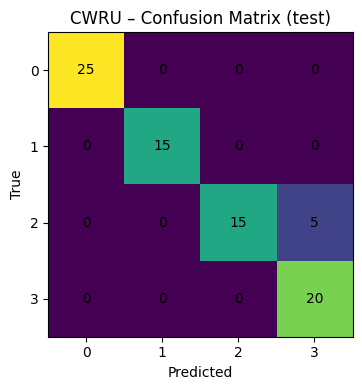

Saved: /content/drive/MyDrive/pdm_project/data/processed/CWRU/cnn_ready/models/cm_test.png


In [17]:
# Save per-sample predictions and a confusion-matrix heatmap
import os, json, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import torch, torch.nn as nn

proc = f"{project_root}/data/processed/CWRU/cnn_ready"
save_dir = os.path.join(proc, "models")
ckpt = os.path.join(save_dir, "cnn1d_cwru_best.pt")

# Reload data
X_test  = np.load(os.path.join(proc, "X_test.npy"))
y_test  = np.load(os.path.join(proc, "y_test.npy"))

# Rebuild model
class CNN1D(nn.Module):
    def __init__(self, in_ch=1, n_classes=4):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv1d(in_ch, 32, 7, padding=3), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, 5, padding=2),   nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64,128, 3, padding=1),   nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.head = nn.Linear(128, n_classes)
    def forward(self, x):
        x = self.feat(x).squeeze(-1)
        return self.head(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN1D(in_ch=X_test.shape[1], n_classes=len(np.unique(y_test))).to(device)
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()

# Predict
with torch.no_grad():
    xb = torch.from_numpy(X_test).float().to(device)
    probs = torch.softmax(model(xb), dim=1).cpu().numpy()
y_pred = probs.argmax(1)

# Save predictions CSV
import pandas as pd
pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    **{f"p_{i}": probs[:, i] for i in range(probs.shape[1])}
})
pred_csv = os.path.join(save_dir, "test_predictions.csv")
pred_df.to_csv(pred_csv, index=False)
print("Saved:", pred_csv)

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4,4))
im = ax.imshow(cm, interpolation='nearest')
ax.set_title("CWRU – Confusion Matrix (test)")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_xticks(range(cm.shape[0])); ax.set_yticks(range(cm.shape[0]))
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()
png_path = os.path.join(save_dir, "cm_test.png")
plt.savefig(png_path, dpi=160); plt.close()
print("Saved:", png_path)


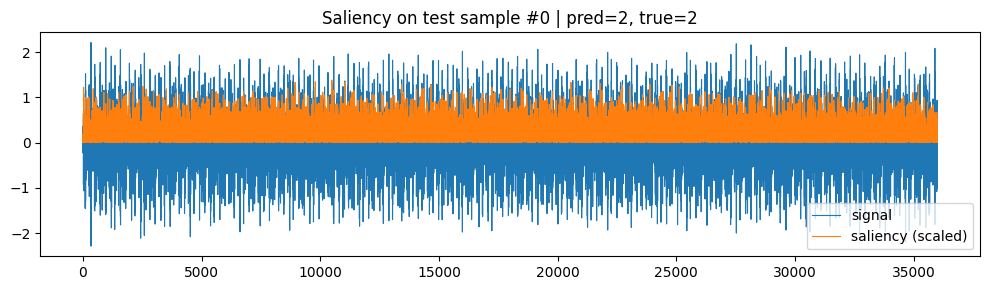

Saved: /content/drive/MyDrive/pdm_project/data/processed/CWRU/cnn_ready/models/saliency_test_0.png


In [19]:
# Saliency for one test sample (choose an index)
import torch
import numpy as np
import matplotlib.pyplot as plt
idx = 0   # change to look at other test signals

xb = torch.from_numpy(X_test[idx:idx+1]).float().to(device)  # (1,1,T)
xb.requires_grad_(True)
logits = model(xb)
pred = logits.argmax(1).item()
score = logits[0, pred]
score.backward()
sal = xb.grad.detach().cpu().numpy()[0,0]      # gradient wrt input
sig = X_test[idx,0]                             # the signal itself

# Normalize saliency for viz
s = (np.abs(sal) / (np.abs(sal).max()+1e-8))

plt.figure(figsize=(10,3))
plt.plot(sig, linewidth=0.8, label="signal")
plt.plot(s * sig.std() * 3, linewidth=0.8, label="saliency (scaled)")
plt.title(f"Saliency on test sample #{idx} | pred={pred}, true={y_test[idx]}")
plt.legend(); plt.tight_layout()
plt.show()
sal_png = os.path.join(save_dir, f"saliency_test_{idx}.png")
plt.savefig(sal_png, dpi=160); plt.close()
print("Saved:", sal_png)


🧠 Pipeline Steps we've Completed

✅ Data intake & windowing (3 s, 50% overlap, 12 kHz → (N,1,36000))

✅ Labeling (4 classes: Normal/B/IR/OR) + metadata.csv

✅ Leakage-safe splits (grouped by source file)

✅ Preprocessing (train-only z-score; optional downsample off)

✅ Baseline CNN trained + saved artifacts


| Step                             | Description                                                                   | Status |
| -------------------------------- | ----------------------------------------------------------------------------- | ------ |
| **1. Data Downloading**          | Downloaded CWRU dataset (bearing signals).                                    | ✅ Done |
| **2. Preprocessing**             | Segmented signals → normalized with z-score → split into train/val/test.      | ✅ Done |
| **3. CNN Model Building**        | Implemented 1D CNN in PyTorch (`CNN1D` class).                                | ✅ Done |
| **4. Model Training**            | Trained CNN on processed CWRU data, monitored metrics, saved best checkpoint. | ✅ Done |
| **5. Model Evaluation**          | Generated predictions, confusion matrix (`cm_test.png`), metrics JSON.        | ✅ Done |
| **6. Explainability (Saliency)** | Computed saliency maps (grad-based interpretability).                         | ✅ Done |
| **7. Output Saving**             | Saved model, plots, and metrics to Drive under structured folders.            | ✅ Done |


✅ Current Results Summary (CWRU Dataset)
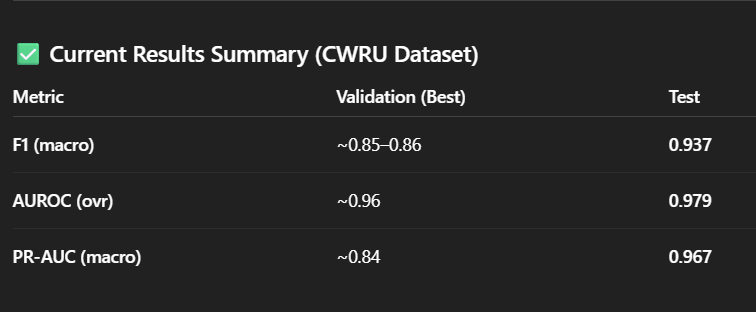

✔️ Confusion matrix: only minor confusion between class 2 and 3

✔️ Saliency visualization: clearly highlights the active vibration regions the CNN “attended to” for classification

✔️ All artifacts saved in /cnn_ready/models/
 → weights .pt, metrics .json, predictions .csv, plots .png

🚧 Next Logical Steps

| Stage                                  | Goal                                                                           | Notes                                                          |
| -------------------------------------- | ------------------------------------------------------------------------------ | -------------------------------------------------------------- |
| **1. Fine-tuning / Transfer Learning** | Use the **pretrained CNN (CWRU)** and fine-tune it on **ESPset_raw**.          | You’ll test how knowledge from CWRU helps ESP (small dataset). |
| **2. Compare Baselines**               | Train a simple **XGBoost** model on manually extracted features (from ESPset). | That’s your *Study 1* baseline (ML approach).                  |
| **3. Build CNN Baseline (ESP-only)**   | Train CNN directly on ESP raw data (without transfer).                         | That’s *Study 2* baseline (DL without pretraining).            |
| **4. Transfer Learning (CWRU → ESP)**  | Load pretrained CNN, freeze early layers, fine-tune final layers on ESP.       | That’s *Study 3* (novelty study).                              |
| **5. Results & Comparison**            | Evaluate all 3 studies on accuracy, F1, and learning behavior.                 | Visualization + Discussion.                                    |


What’s next (you can pick one):

📊 XGBoost Baseline (Study 1 – ML approach)
→ We’ll extract RMS, kurtosis, skewness, etc. from each window and train XGBoost to compare with CNN.

🔁 Transfer Learning (Study 3 – CWRU → ESPset)
→ Load this trained CNN, freeze early conv layers, replace the head, and fine-tune on your smaller ESPset dataset.

🧩 XAI Enhancement
→ Add Grad-CAM 1D or Integrated Gradients to visualize which time-segments the CNN relies on most.
